<a href="https://colab.research.google.com/github/TurdibekovBegzod/Computer-Vision_Text-Detection/blob/main/Text_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from easyocr import Reader
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
import torch

In [25]:
# import torch

# print(torch.__version__)
# print(torch.version.cuda)
# print(torch.cuda.is_available())
# torch.cuda.set_device(1)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
e:\Programming\Projects\AI\Computer Vision\Computer-Vision_Text-Detection\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


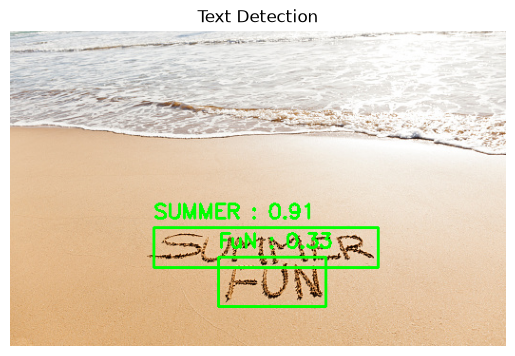

In [26]:
image_path = 'Images/summer_fun.jpg'


reader = Reader(['en'], gpu=True)
image = cv2.imread(image_path, cv2.IMREAD_COLOR_RGB)
results = reader.readtext(image)

for bbox, text, confidence in results:
    points = np.array(bbox, dtype=np.int32)

    x_min = int(points[:,0].min())
    y_min = int(points[:,1].min())
    x_max = int(points[:,0].max())
    y_max = int(points[:,1].max())

    cv2.rectangle(image, (x_min, y_min), (x_max, y_max), color=[0, 255, 0], thickness=2)
    cv2.putText(
    image,
    text=f"{text} : {confidence:.2f}",
    org=(x_min, y_min - 10),
    fontFace=cv2.FONT_HERSHEY_SIMPLEX,
    fontScale=0.7,
    color=(0, 255, 0),
    thickness=2
)


plt.title("Text Detection")
plt.axis('off')
plt.imshow(image)



## Calculate the accuracy

In [27]:
path = os.getcwd()
images_path = os.path.join(path, 'Images')

reader = Reader(['en'], gpu=True)



gt = list()
pt = list()


for image_path in os.listdir(images_path):
    image_name, _ = image_path.split('.')
    image_name = image_name.replace('_', ' ').lower()

    gt.append(image_name) # added the true image name

    results= reader.readtext(os.path.join(images_path, image_path))
    predicted_text = ""
    for _, text, _ in results:
        predicted_text += text + ' '
    
    pt.append(predicted_text.strip().lower()) # added the predicted text

print()

# 
scores = list()
for ground_text, predicted_text in zip(gt, pt):
    score = SequenceMatcher(None, ground_text, predicted_text).ratio() # calculate the score between two texts(ground text, predicted text)
    scores.append(score)

avg_score = sum(scores) / len(scores) # calculate the avg score
for ground_text, predicted_text in zip(gt, pt):
    print('gt :', ground_text, '| pt :', predicted_text)

print()

print(f"Accuracy : {avg_score :.2f}")






Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
e:\Programming\Projects\AI\Computer Vision\Computer-Vision_Text-Detection\venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
e:\Programming\Projects\AI\Computer Vision\Computer-Vision_Text-Detection\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
e:\Programming\Projects\AI\Computer Vision\Computer-Vision_Text-Detection\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
e:\Programming\Projects\AI\Computer Vision\Computer-Vision_Text-Detection\venv\Lib\site-packages\torch\uti


gt : add text to image | pt : add text to image
gt : bold | pt : bold
gt : do you speak english | pt : do you speak english?
gt : how to combine text and image in elearning design | pt : how to combine text and image in elearning design
gt : learn english | pt : learn english
gt : share your story | pt : share your storyl
gt : smile | pt : smile
gt : summer fun | pt : summer fun

Accuracy : 0.99
